In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
%matplotlib inline
import seaborn as sns

In [2]:
df=pd.read_csv("C:/Users/nandh/Downloads/archive (12)/Crop_recommendation.csv")

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
def assign_disease(row):
    if row['humidity'] > 80 and row['rainfall'] > 120:
        return 'Fungal'
    elif row['temperature'] > 35 and row['ph'] < 6:
        return 'Bacterial'
    elif row['humidity'] < 40 and row['temperature'] < 20:
        return 'Viral'
    else:
        return 'No Disease'

In [6]:
df['disease'] = df.apply(assign_disease, axis=1)

In [7]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,disease
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,Fungal
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,Fungal
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,Fungal
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,Fungal
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,Fungal


In [8]:
df.shape

(2200, 9)

In [9]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['disease']

In [73]:
df['label'].value_counts()

label
20    100
11    100
8     100
6     100
4     100
17    100
16    100
0     100
15    100
21    100
7     100
12    100
1     100
19    100
10    100
2     100
14    100
13    100
18    100
9     100
3     100
5     100
Name: count, dtype: int64

In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [12]:
le = LabelEncoder()
y_encoded = le.fit_transform(y) 

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

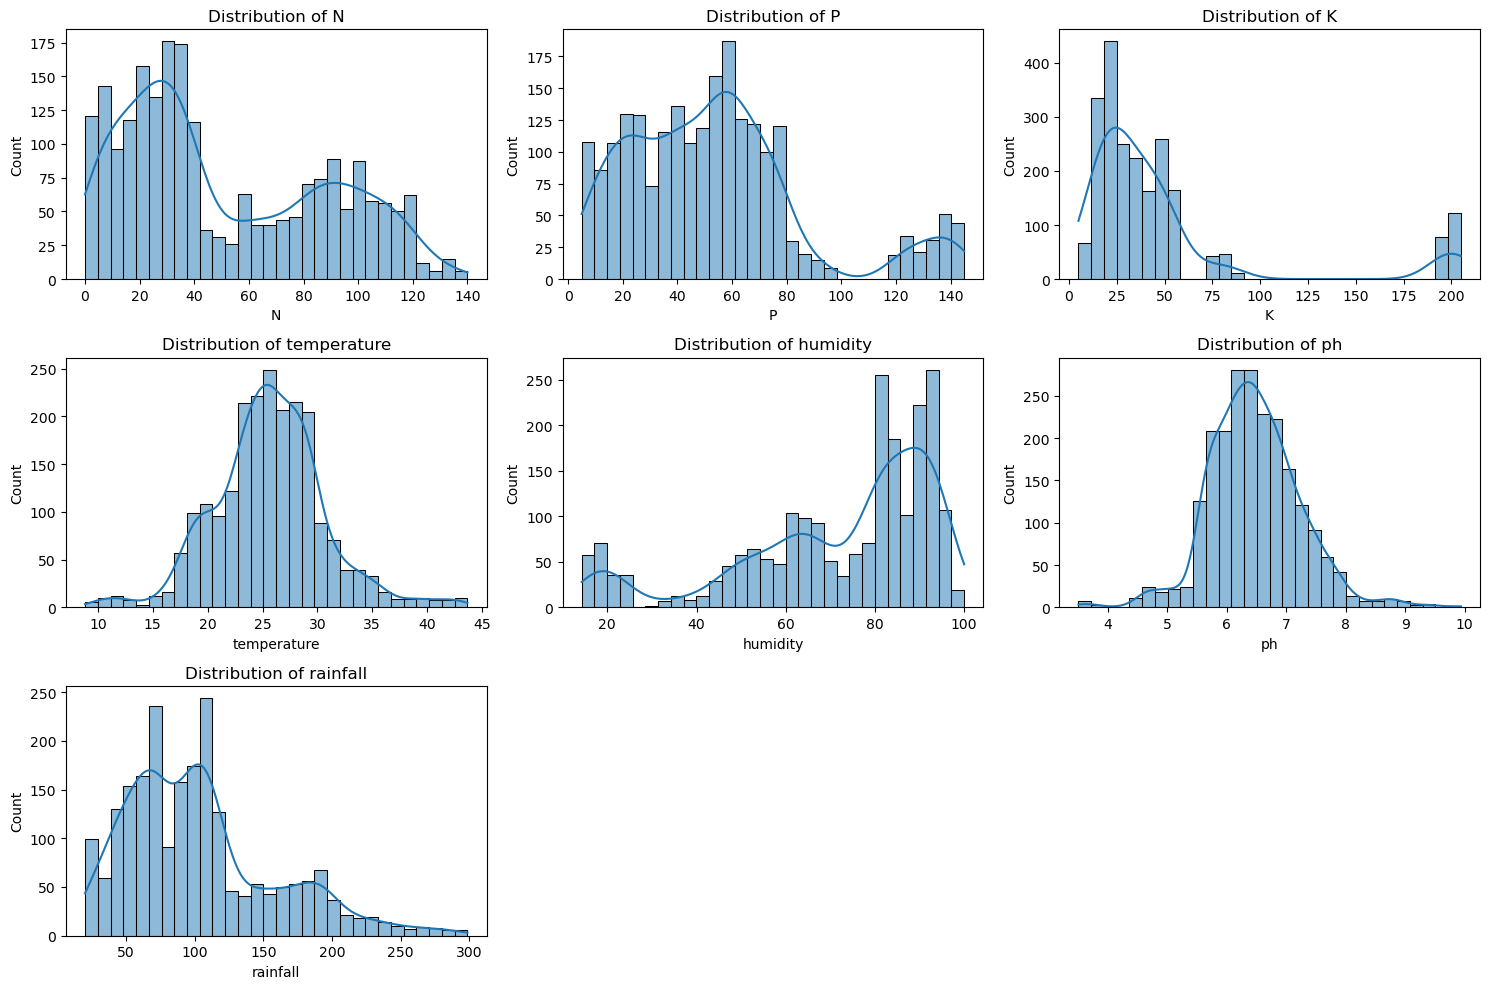

In [17]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

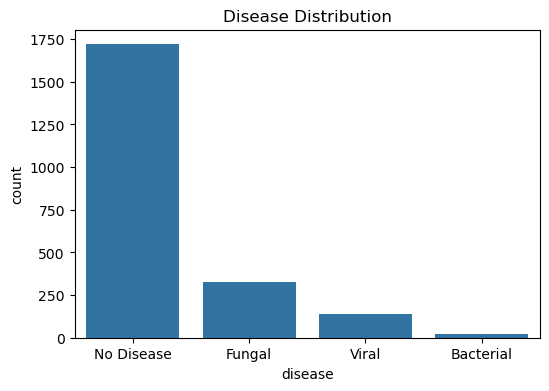

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='disease', order=df['disease'].value_counts().index)
plt.title('Disease Distribution')
plt.show()

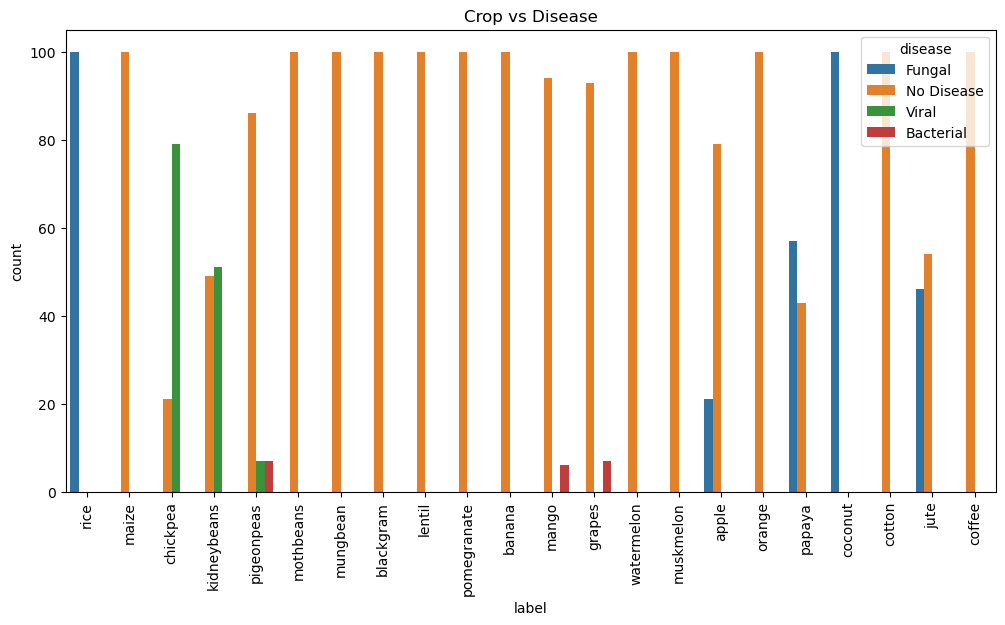

In [22]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='label', hue='disease')
plt.xticks(rotation=90)
plt.title('Crop vs Disease')
plt.show()

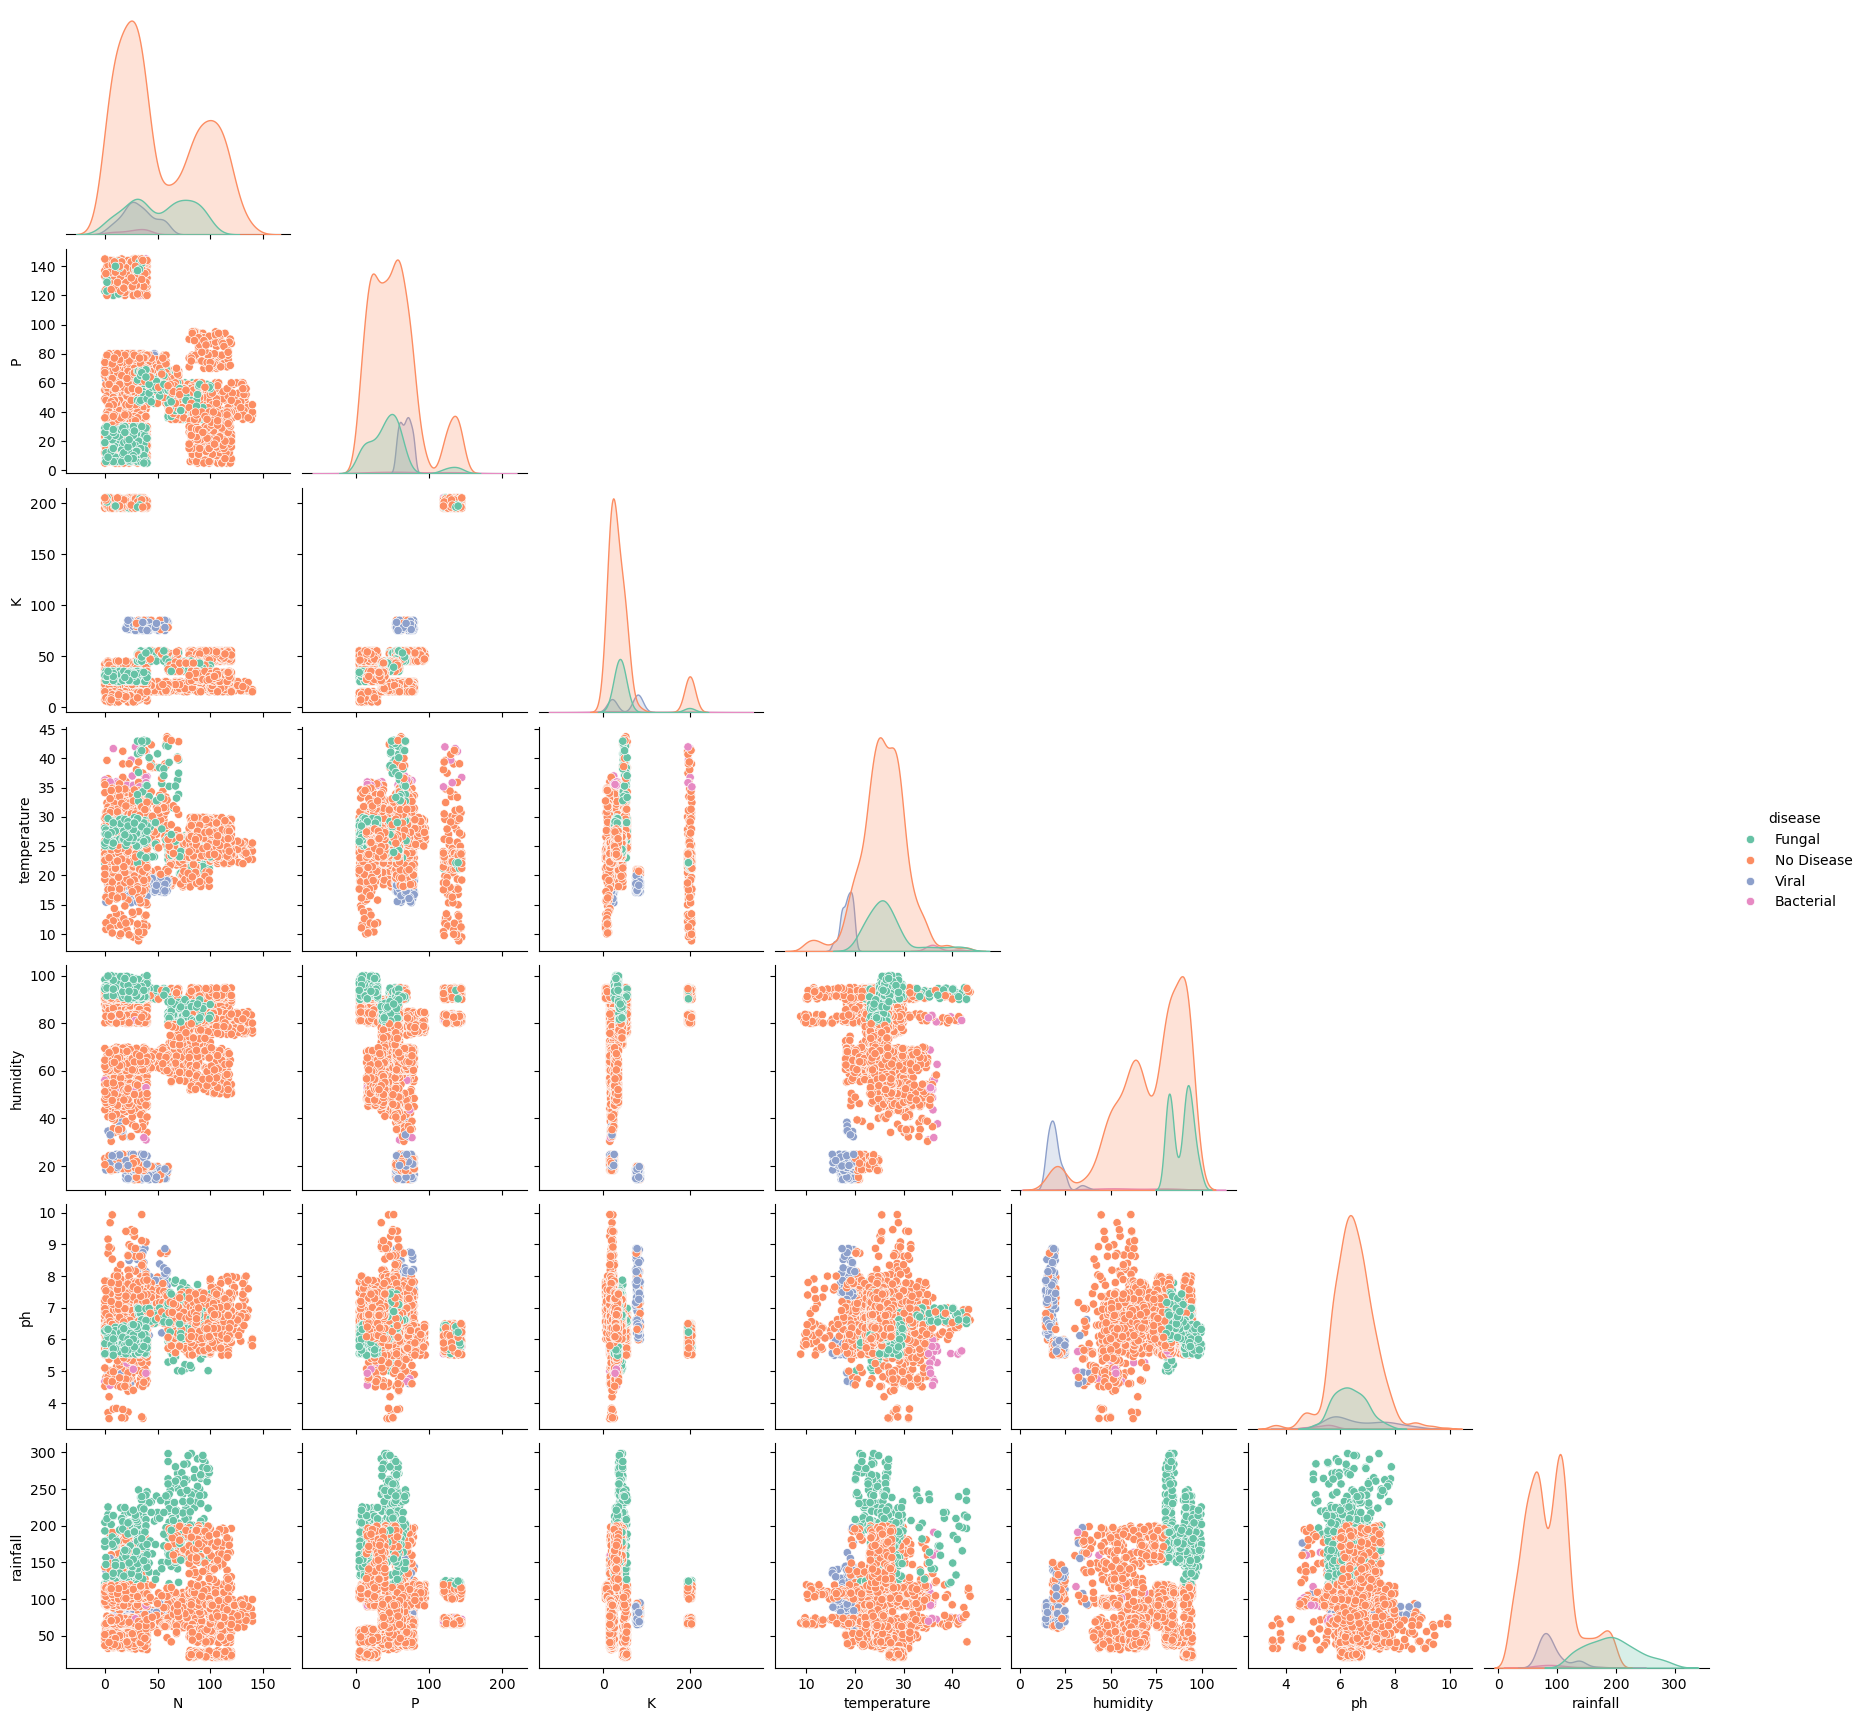

In [24]:
sns.pairplot(df, vars=numeric_cols, hue='disease', palette='Set2', corner=True)
plt.show()

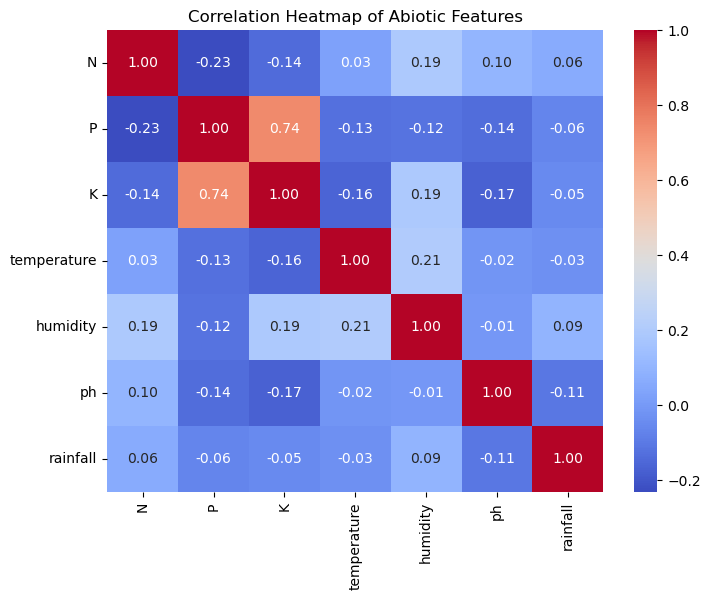

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr = df[features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Abiotic Features")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

In [27]:
# Create encoder objects
le_crop = LabelEncoder()
le_disease = LabelEncoder()

# Fit and transform
df['label'] = le_crop.fit_transform(df['label'])
df['disease'] = le_disease.fit_transform(df['disease'])

# Check encoding
print(df[['label', 'disease']].head())

   label  disease
0     20        1
1     20        1
2     20        1
3     20        1
4     20        1


In [29]:
print(df['disease'].value_counts())

disease
2    1719
1     324
3     137
0      20
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import LabelEncoder

le_disease = LabelEncoder()
df['disease'] = le_disease.fit_transform(df['disease'])

# Check encoding
print(df['disease'].value_counts())

disease
2    1719
1     324
3     137
0      20
Name: count, dtype: int64


In [32]:
print(df['label'].value_counts())

label
20    100
11    100
8     100
6     100
4     100
17    100
16    100
0     100
15    100
21    100
7     100
12    100
1     100
19    100
10    100
2     100
14    100
13    100
18    100
9     100
3     100
5     100
Name: count, dtype: int64


In [34]:

X = df[['label','N','P','K','temperature','humidity','ph','rainfall']]

# Target
y = df['disease']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['N','P','K','temperature','humidity','ph','rainfall']
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [53]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       1.00      1.00      1.00        65
           2       0.99      1.00      1.00       344
           3       1.00      0.93      0.96        27

    accuracy                           0.99       440
   macro avg       1.00      0.92      0.95       440
weighted avg       0.99      0.99      0.99       440



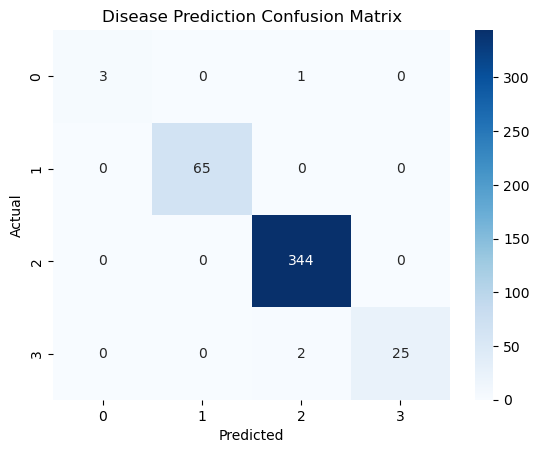

In [39]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Disease Prediction Confusion Matrix')
plt.show()

<Figure size 1000x600 with 0 Axes>

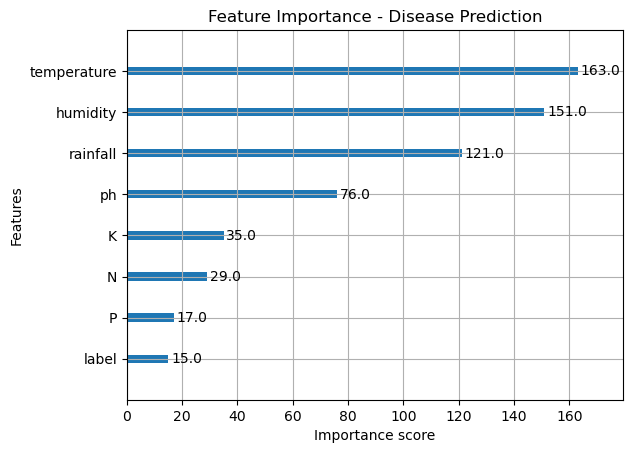

In [40]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance
plt.figure(figsize=(10,6))
plot_importance(model, importance_type='weight', max_num_features=10)
plt.title("Feature Importance - Disease Prediction")
plt.show()

C:\Users\nandh\AppData\Local\Temp\ipykernel_3680\2701838756.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


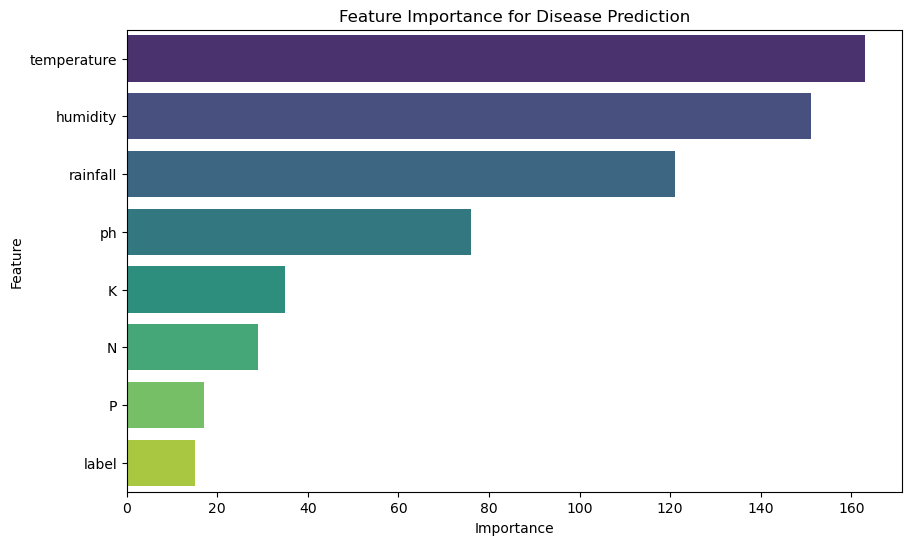

In [41]:
import pandas as pd
import seaborn as sns

# Get feature importance
importance = model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance for Disease Prediction")
plt.show()

In [42]:
from imblearn.over_sampling import SMOTE

In [44]:
# Features include crop + soil/environmental features
X = df[['label','N','P','K','temperature','humidity','ph','rainfall']]
y = df['disease']

# Train-test split (stratify by y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
numeric_cols = ['N','P','K','temperature','humidity','ph','rainfall']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [46]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print(pd.Series(y_train_res).value_counts())

disease
2    1375
3    1375
1    1375
0    1375
Name: count, dtype: int64


In [47]:
model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train_res, y_train_res)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       1.00      1.00      1.00        65
           2       0.99      1.00      1.00       344
           3       1.00      0.96      0.98        27

    accuracy                           0.99       440
   macro avg       0.94      0.93      0.93       440
weighted avg       0.99      0.99      0.99       440



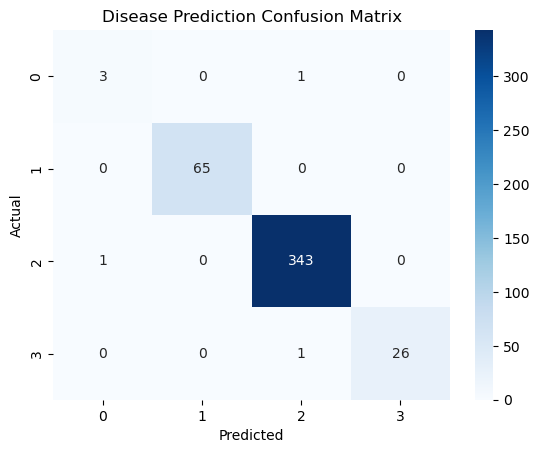

In [48]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Disease Prediction Confusion Matrix')
plt.show()

C:\Users\nandh\AppData\Local\Temp\ipykernel_3680\3062747591.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


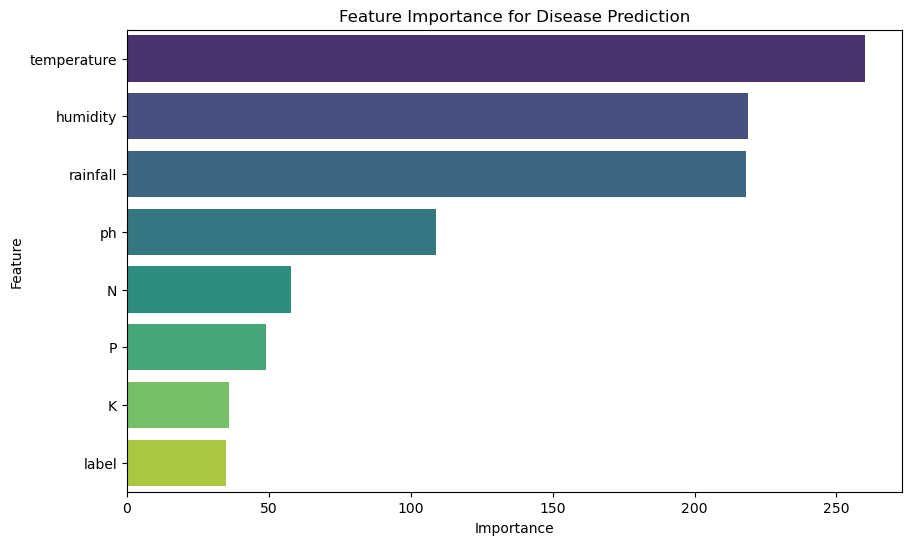

In [49]:
# Get feature importance from XGBoost
importance = model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance for Disease Prediction")
plt.show()

In [50]:
y_pred = model.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9932


In [55]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Fungal', 'Bacterial', 'Viral']))

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.75      0.75      0.75         4
      Fungal       1.00      1.00      1.00        65
   Bacterial       0.99      1.00      1.00       344
       Viral       1.00      0.96      0.98        27

    accuracy                           0.99       440
   macro avg       0.94      0.93      0.93       440
weighted avg       0.99      0.99      0.99       440



In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(objective='multi:softmax', num_class=4, random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1
)

grid.fit(X_train_res, y_train_res)
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


In [58]:
# Assuming you already ran GridSearchCV or RandomizedSearchCV
best_model = grid.best_estimator_  # or rand_search.best_estimator_

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9932


In [60]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Disease', 'Fungal', 'Bacterial', 'Viral']
))

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.75      0.75      0.75         4
      Fungal       1.00      1.00      1.00        65
   Bacterial       0.99      1.00      1.00       344
       Viral       1.00      0.96      0.98        27

    accuracy                           0.99       440
   macro avg       0.94      0.93      0.93       440
weighted avg       0.99      0.99      0.99       440



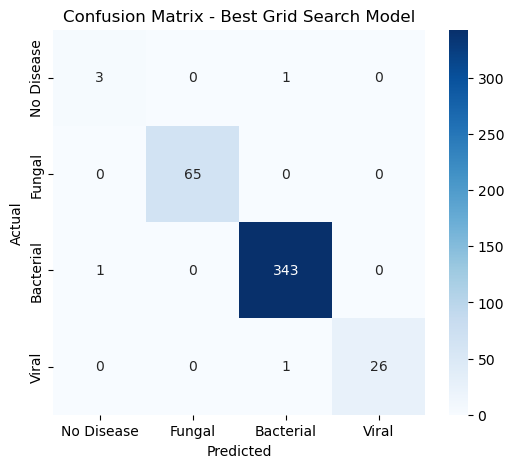

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Fungal','Bacterial','Viral'],
            yticklabels=['No Disease','Fungal','Bacterial','Viral'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Grid Search Model')
plt.show()

In [62]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_df = pd.DataFrame({
    'Class': ['No Disease','Fungal','Bacterial','Viral'],
    'Precision': precision_score(y_test, y_pred, average=None),
    'Recall': recall_score(y_test, y_pred, average=None),
    'F1-score': f1_score(y_test, y_pred, average=None),
    'Support': pd.Series(y_test).value_counts().sort_index().values
})

print(metrics_df)

        Class  Precision    Recall  F1-score  Support
0  No Disease   0.750000  0.750000  0.750000        4
1      Fungal   1.000000  1.000000  1.000000       65
2   Bacterial   0.994203  0.997093  0.995646      344
3       Viral   1.000000  0.962963  0.981132       27


In [74]:
import pandas as pd
import joblib

# Load objects
model = joblib.load('xgb_disease_model.pkl')
scaler = joblib.load('scaler.pkl')
crop_mapping = joblib.load('crop_mapping.pkl')       # e.g., {'apple':0, 'banana':1, ...}
disease_mapping = joblib.load('disease_mapping.pkl') # e.g., {0:'No Disease',1:'Fungal',...}

def predict_disease(crop_name, N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict crop disease.

    Parameters:
        crop_name (str): Crop as string, e.g., 'apple'
        N, P, K (float): Soil nutrients
        temperature, humidity, ph, rainfall (float): Environmental features

    Returns:
        str: Predicted disease name
    """
    # Convert crop string to numeric label
    label = crop_mapping.get(crop_name.lower())
    if label is None:
        return "Unknown Crop"
    
    # Prepare input dataframe
    df_input = pd.DataFrame([{
        'label': label,
        'N': N,
        'P': P,
        'K': K,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall
    }])
    
    # Scale numeric features
    numeric_cols = ['N','P','K','temperature','humidity','ph','rainfall']
    df_input[numeric_cols] = scaler.transform(df_input[numeric_cols])
    
    # Predict numeric label
    pred_numeric = model.predict(df_input)[0]
    
    # Map numeric label to disease name
    disease_name = disease_mapping.get(pred_numeric, "Unknown")
    
    return disease_name

In [75]:

new_sample = {
    'label': 20,         
    'N': 50,            
    'P': 60,           
    'K': 40,            
    'temperature': 30,  
    'humidity': 85,     
    'ph': 6.5,           # Soil pH
    'rainfall': 120      # Rainfall in mm
}

In [76]:
# Predict disease
disease = main_predict(model, scaler, new_sample)
print("Predicted Disease:", disease)

Predicted Disease: Fungal


In [83]:
# Example inputs for testing disease prediction
inputs = [
    {
        'label': 20,        # Crop: Wheat
        'N': 50,
        'P': 60,
        'K': 40,
        'temperature': 30,
        'humidity': 85,
        'ph': 6.5,
        'rainfall': 120
    },
    {
        'label': 11,        # Crop: Rice
        'N': 30,
        'P': 45,
        'K': 35,
        'temperature': 28,
        'humidity': 90,
        'ph': 5.8,
        'rainfall': 180
    },
    {
        'label': 8,         # Crop: Maize
        'N': 40,
        'P': 50,
        'K': 45,
        'temperature': 32,
        'humidity': 75,
        'ph': 6.2,
        'rainfall': 100
    },
    {
        'label': 6,         # Crop: Barley
        'N': 25,
        'P': 40,
        'K': 30,
        'temperature': 22,
        'humidity': 60,
        'ph': 6.8,
        'rainfall': 80
    },
    {
        'label': 17,        # Crop: Sugarcane
        'N': 55,
        'P': 65,
        'K': 50,
        'temperature': 33,
        'humidity': 95,
        'ph': 6.0,
        'rainfall': 200
    }
]

# Predict disease for all inputs
for i, sample in enumerate(inputs):
    disease = main_predict(model, scaler, sample)
    print(f"Sample {i+1} Predicted Disease: {disease}")

Sample 1 Predicted Disease: Fungal
Sample 2 Predicted Disease: Fungal
Sample 3 Predicted Disease: Bacterial
Sample 4 Predicted Disease: Bacterial
Sample 5 Predicted Disease: Fungal


In [78]:
import joblib

# After training your model and scaler
# model, scaler = main(df)  # if using your training pipeline

# Save XGBoost model
joblib.dump(model, 'xgb_disease_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save disease mapping (numeric to label)
disease_mapping = {0: 'No Disease', 1: 'Fungal', 2: 'Bacterial', 3: 'Viral'}
joblib.dump(disease_mapping, 'disease_mapping.pkl')

print("Model, scaler, and mappings saved successfully!")

Model, scaler, and mappings saved successfully!


In [79]:
disease_mapping = {
    0: 'No Disease',
    1: 'Fungal',
    2: 'Bacterial',
    3: 'Viral'
}

In [80]:
import joblib
joblib.dump(disease_mapping, 'disease_mapping.pkl')

['disease_mapping.pkl']

In [81]:

# Show mapping
crop_mapping = dict(zip(le_crop.classes_, le_crop.transform(le_crop.classes_)))
disease_mapping = dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_)))

print("Crop Mapping:", crop_mapping)
print("Disease Mapping:", disease_mapping)

Crop Mapping: {'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}
Disease Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}


In [72]:
import joblib

crop_mapping = {
    'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5,
    'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11,
    'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16,
    'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21
}

joblib.dump(crop_mapping, 'crop_mapping.pkl')

['crop_mapping.pkl']

In [84]:
new_sample = {
    'label': 40,         # Crop numeric label (e.g., 20 could be 'Wheat', map according to your dataset)
    'N': 40,             # Nitrogen content in soil
    'P': 40,             # Phosphorus content
    'K': 25,             # Potassium content
    'temperature': 50,   # Temperature in °C
    'humidity': 85,      # Humidity in %
    'ph': 6.5,           # Soil pH
    'rainfall': 120      # Rainfall in mm
}

In [85]:
disease = main_predict(model, scaler, new_sample)
print("Predicted Disease:", disease)

Predicted Disease: Bacterial
